Shape of dataset: (9240, 37)

First 5 rows:
                            Prospect ID  Lead Number              Lead Origin  \
0  7927b2df-8bba-4d29-b9a2-b6e0beafe620       660737                      API   
1  2a272436-5132-4136-86fa-dcc88c88f482       660728                      API   
2  8cc8c611-a219-4f35-ad23-fdfd2656bd8a       660727  Landing Page Submission   
3  0cc2df48-7cf4-4e39-9de9-19797f9b38cc       660719  Landing Page Submission   
4  3256f628-e534-4826-9d63-4a8b88782852       660681  Landing Page Submission   

      Lead Source Do Not Email Do Not Call  Converted  TotalVisits  \
0      Olark Chat           No          No          0          0.0   
1  Organic Search           No          No          0          5.0   
2  Direct Traffic           No          No          1          2.0   
3  Direct Traffic           No          No          0          1.0   
4          Google           No          No          1          2.0   

   Total Time Spent on Website  Page Views Per V

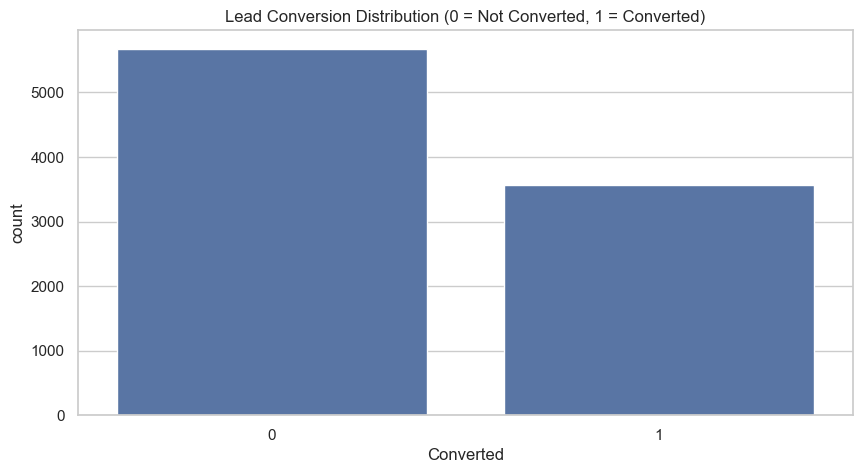


Converted Value Counts:
Converted
0    61.461039
1    38.538961
Name: proportion, dtype: float64


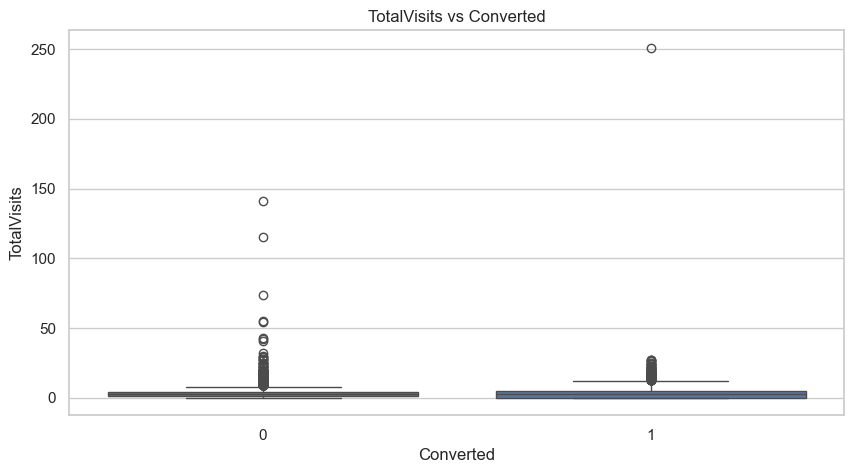

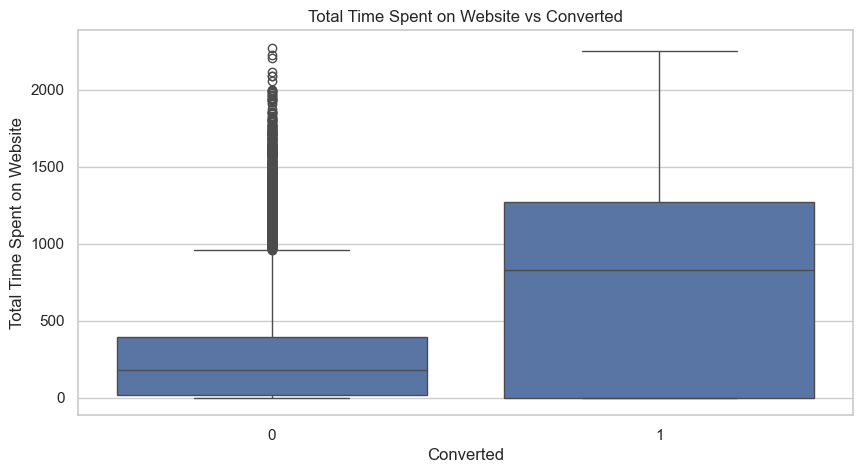

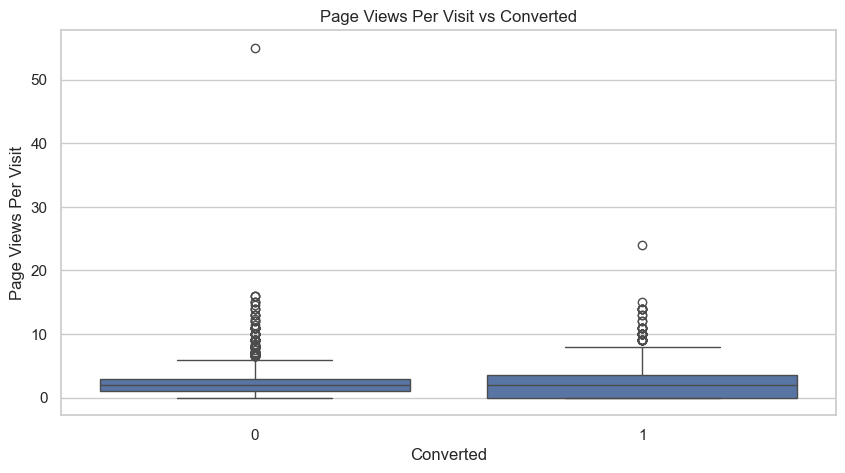

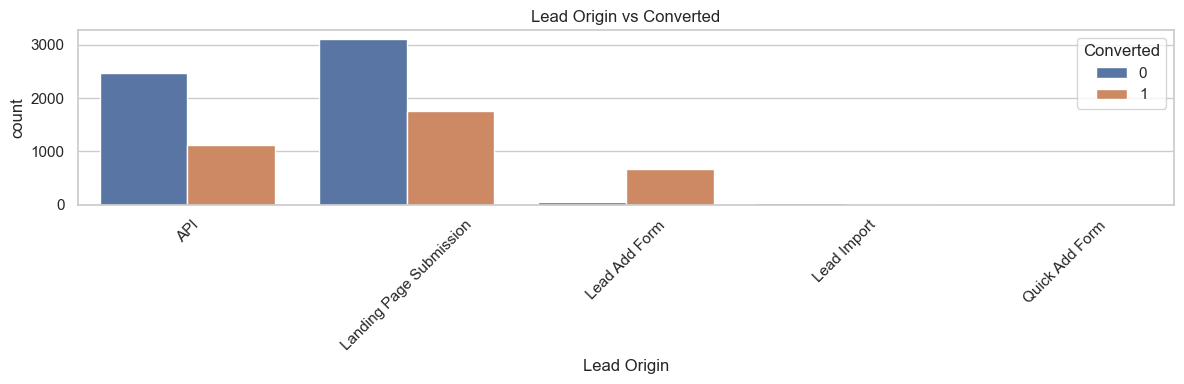

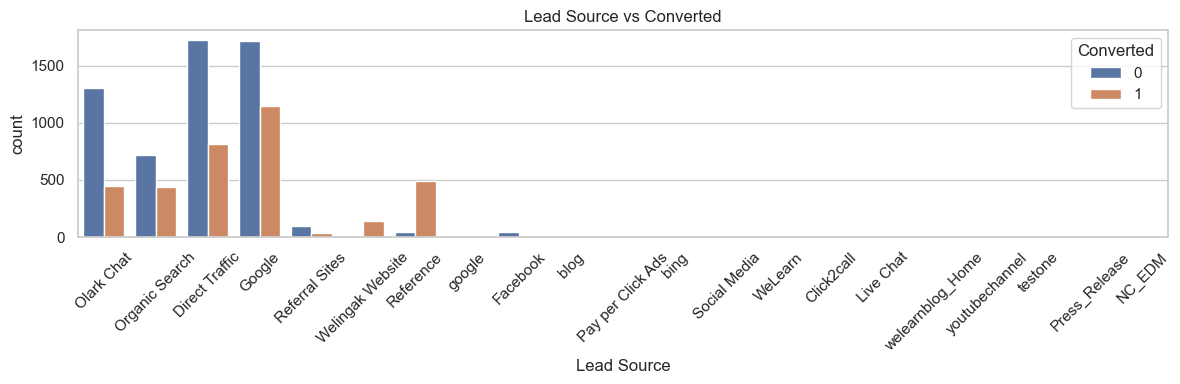

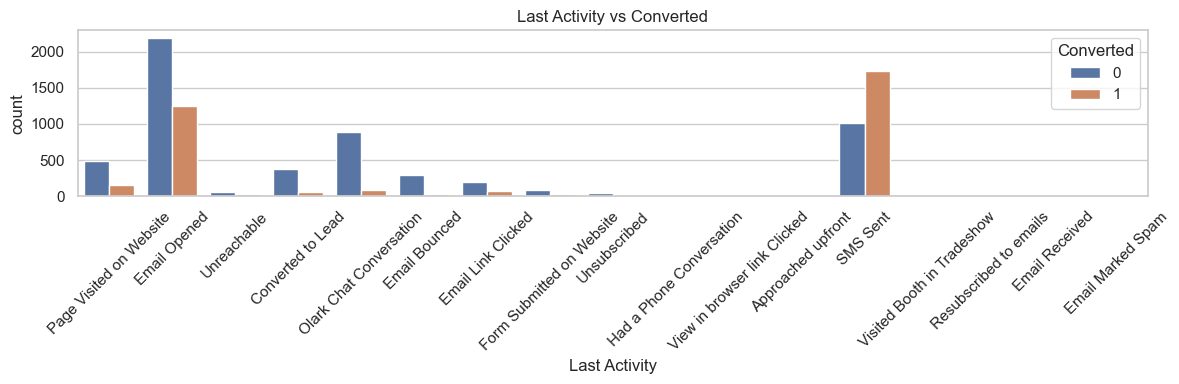

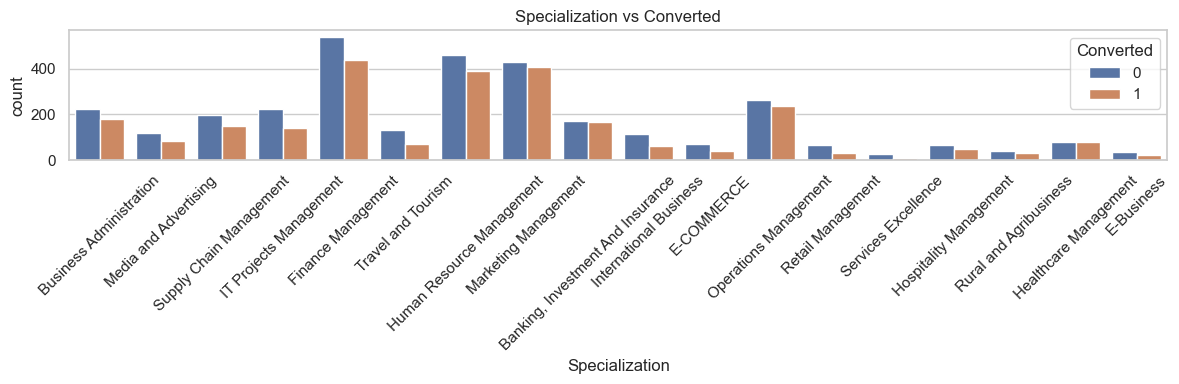

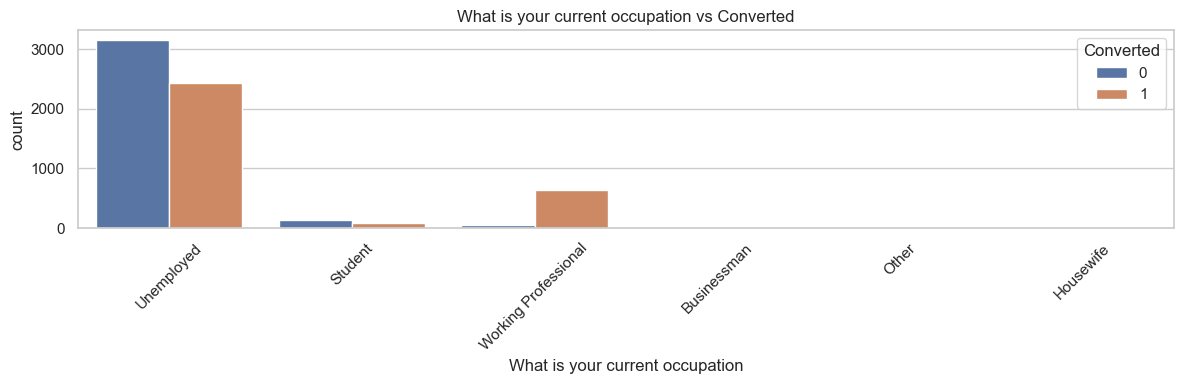

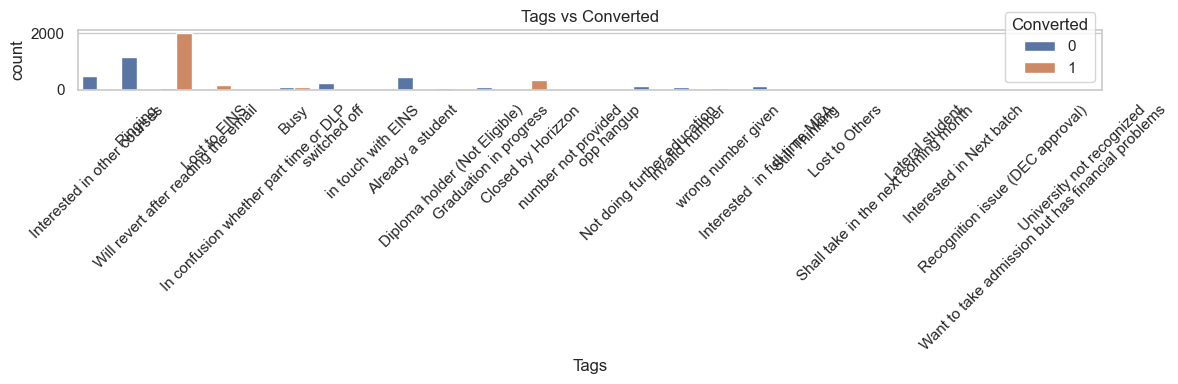

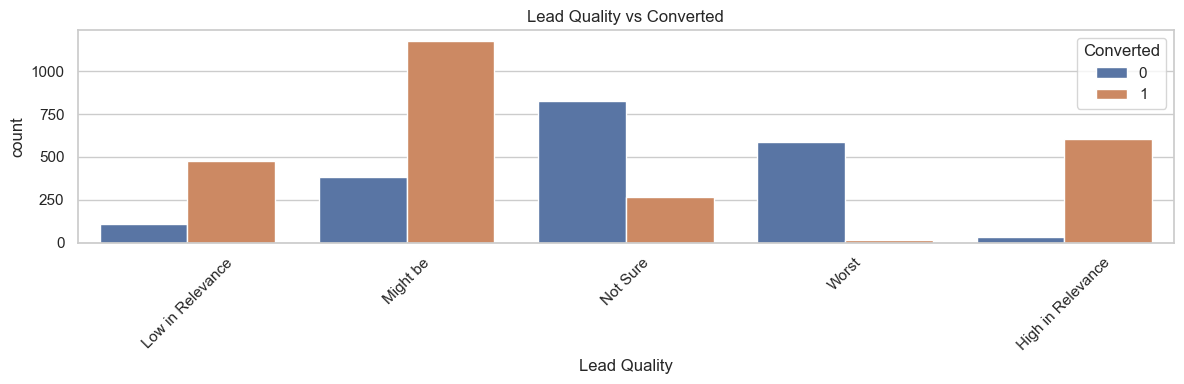

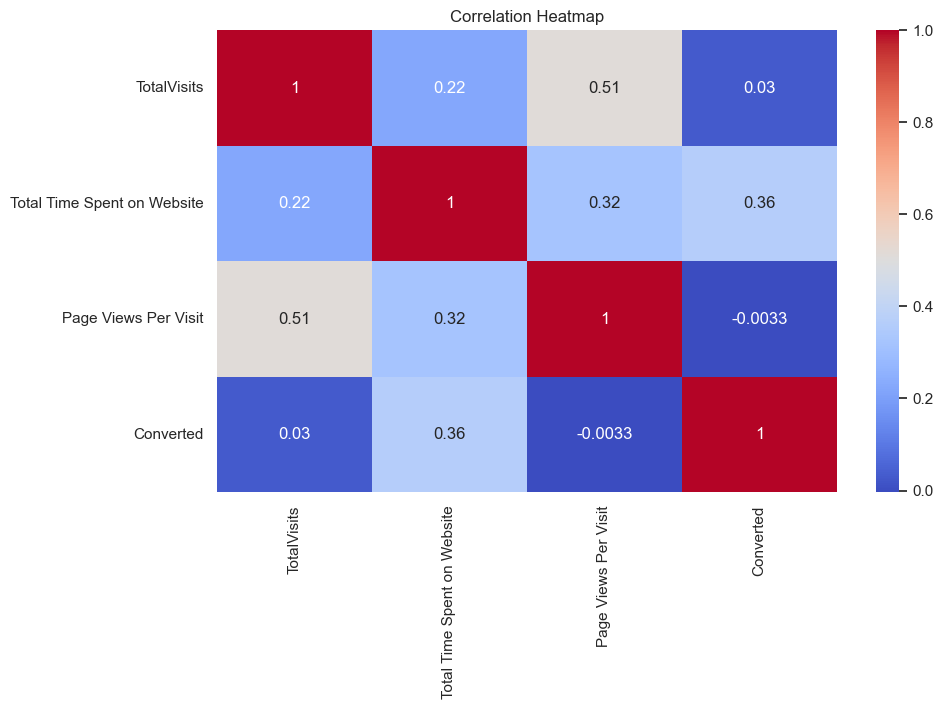


✅ One-hot encoding done. Final feature shape: (9240, 185)

📏 Numerical features scaled: ['TotalVisits', 'Total Time Spent on Website', 'Page Views Per Visit', 'Asymmetrique Activity Score', 'Asymmetrique Profile Score']

🧼 Dropped rows with missing values: 4305 rows removed

🔀 Data Split Complete:
Train Set: (3454, 185), Test Set: (1481, 185)
✅ Logistic Regression model trained successfully.
📊 Evaluation Metrics on Test Data:

Accuracy : 0.9345
Precision: 0.9405
Recall   : 0.8813
F1-Score : 0.9099
ROC-AUC  : 0.9712


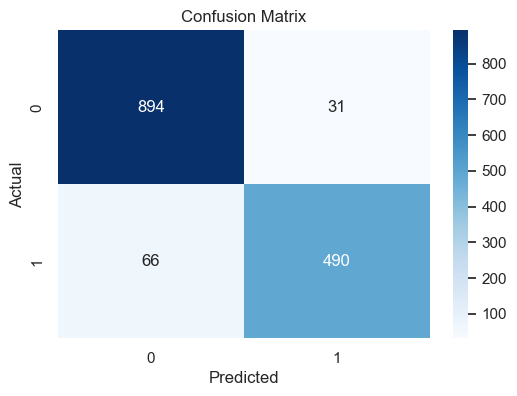

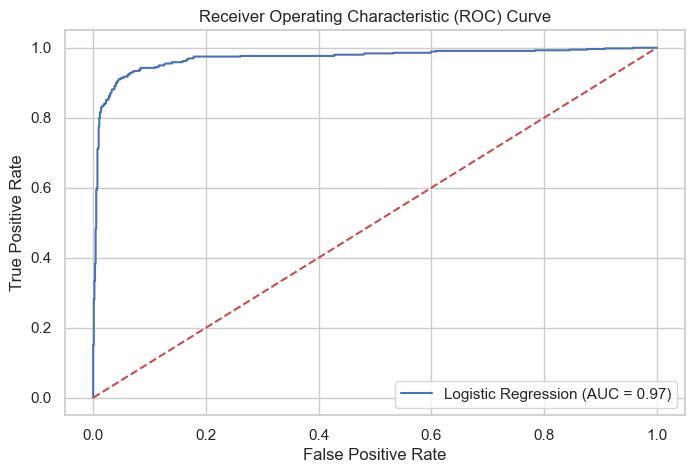


🎯 Sample Leads with Lead Scores:
   Converted  Lead Score
0          0        2.20
1          0        5.20
2          1       97.73
3          0        0.08
4          1       98.70
5          0        4.27
6          1       96.59
7          0        2.99
8          0        1.42
9          0        1.91


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For model building and evaluation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

# To ignore warnings
import warnings
warnings.filterwarnings("ignore")

# 2. Load the Leads Dataset
df = pd.read_csv("Leads.csv")

# 3. Initial Exploration

# Shape of the dataset
print("Shape of dataset:", df.shape)

# First 5 rows
print("\nFirst 5 rows:")
print(df.head())

# Basic info about dataset (column names, datatypes, nulls)
print("\nData Info:")
print(df.info())

# Summary statistics for numerical columns
print("\nStatistical Summary:")
print(df.describe())

# Checking number of missing values per column
print("\nMissing Values Count:")
print(df.isnull().sum().sort_values(ascending=False))

import numpy as np

# Copy original dataset
df_cleaned = df.copy()

# 4.1 Drop unique ID columns
df_cleaned.drop(['Prospect ID', 'Lead Number'], axis=1, inplace=True)

# 4.2 Replace 'Select' and similar placeholder values with NaN
df_cleaned.replace(['Select', 'Select Specialization'], np.nan, inplace=True)

# 4.3 List of binary columns with Yes/No to be converted to 1/0
binary_cols = [
    'Do Not Email',
    'Do Not Call',
    'Search',
    'Magazine',
    'Newspaper Article',
    'X Education Forums',
    'Newspaper',
    'Digital Advertisement',
    'Through Recommendations',
    'Receive More Updates About Our Courses',
    'Update me on Supply Chain Content',
    'Get updates on DM Content',
    'I agree to pay the amount through cheque',
    'A free copy of Mastering The Interview'  # Correct capitalized column name
]

existing_binary_cols = [col for col in binary_cols if col in df_cleaned.columns]

# Convert Yes/No to 1/0
for col in existing_binary_cols:
    df_cleaned[col] = df_cleaned[col].map({'Yes': 1, 'No': 0})

print(f"\n✔️ Converted {len(existing_binary_cols)} binary columns to 1/0.")

# 4.4 Show missing value summary
missing_counts = df_cleaned.isnull().sum()
missing_percent = round(100 * (missing_counts / len(df_cleaned)), 2)

missing_df = pd.DataFrame({
    'Missing Values': missing_counts,
    'Percentage (%)': missing_percent
})

print("\n🧼 Columns with missing values:")
print(missing_df[missing_df['Missing Values'] > 0].sort_values(by='Percentage (%)', ascending=False))


import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

# 5.1 Target Variable Distribution
print("\n🎯 Target Variable Distribution:")
sns.countplot(x='Converted', data=df_cleaned)
plt.title("Lead Conversion Distribution (0 = Not Converted, 1 = Converted)")
plt.show()

print("\nConverted Value Counts:")
print(df_cleaned['Converted'].value_counts(normalize=True) * 100)

# 5.2 Numerical Columns vs Target
numerical_cols = ['TotalVisits', 'Total Time Spent on Website', 'Page Views Per Visit']

for col in numerical_cols:
    sns.boxplot(x='Converted', y=col, data=df_cleaned)
    plt.title(f'{col} vs Converted')
    plt.show()

# 5.3 Top Categorical Variables Distribution
categorical_cols = ['Lead Origin', 'Lead Source', 'Last Activity', 'Specialization',
                    'What is your current occupation', 'Tags', 'Lead Quality']

for col in categorical_cols:
    if col in df_cleaned.columns:
        plt.figure(figsize=(12, 4))
        sns.countplot(x=col, hue='Converted', data=df_cleaned)
        plt.xticks(rotation=45)
        plt.title(f'{col} vs Converted')
        plt.tight_layout()
        plt.show()

# 5.4 Correlation Heatmap (numerical values only)
plt.figure(figsize=(10, 6))
sns.heatmap(df_cleaned[numerical_cols + ['Converted']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


from sklearn.preprocessing import StandardScaler

# 6.1 Separate Features and Target
X = df_cleaned.drop('Converted', axis=1)
y = df_cleaned['Converted']

# 6.2 One-hot encoding for categorical variables
categorical_cols = X.select_dtypes(include='object').columns.tolist()
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print(f"\n✅ One-hot encoding done. Final feature shape: {X.shape}")

# 6.3 Scaling Numerical Features
numerical_cols = ['TotalVisits', 'Total Time Spent on Website', 'Page Views Per Visit',
                  'Asymmetrique Activity Index', 'Asymmetrique Profile Index',
                  'Asymmetrique Activity Score', 'Asymmetrique Profile Score']

# Filter only existing numerical columns
numerical_cols = [col for col in numerical_cols if col in X.columns]

scaler = StandardScaler()
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

print(f"\n📏 Numerical features scaled: {numerical_cols}")

# 6.4 Handle Missing Values (Drop rows with any missing value)
initial_shape = X.shape
X = X.dropna()
y = y[X.index]  # Align target with filtered features

print(f"\n🧼 Dropped rows with missing values: {initial_shape[0] - X.shape[0]} rows removed")



from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# 7.1 Split the data (70% training, 30% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"\n🔀 Data Split Complete:")
print(f"Train Set: {X_train.shape}, Test Set: {X_test.shape}")

# 7.2 Train Logistic Regression Model
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)

print("✅ Logistic Regression model trained successfully.")






from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve

# 8.1 Predict on Test Set
y_pred = logreg.predict(X_test)
y_pred_proba = logreg.predict_proba(X_test)[:, 1]  # probability for class 1 (converted)

# 8.2 Evaluation Metrics
print("📊 Evaluation Metrics on Test Data:\n")
print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall   :", round(recall_score(y_test, y_pred), 4))
print("F1-Score :", round(f1_score(y_test, y_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_pred_proba), 4))

# 8.3 Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 8.4 ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8,5))
plt.plot(fpr, tpr, label='Logistic Regression (AUC = %0.2f)' % roc_auc_score(y_test, y_pred_proba))
plt.plot([0, 1], [0, 1],'r--')  # random guess line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.grid(True)
plt.show()



lead_scores = logreg.predict_proba(X)[:, 1]  # Probability of being converted

lead_scores_percent = np.round(lead_scores * 100, 2)

final_leads = df_cleaned.loc[X.index].copy()
final_leads['Lead Score'] = lead_scores_percent

print("\n🎯 Sample Leads with Lead Scores:")
print(final_leads[['Converted', 'Lead Score']].head(10))
